In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from matchmaker.dp.oltw_dixon import (FRAME_RATE, HOP_LENGTH, SAMPLE_RATE,
                                      OnlineTimeWarpingDixon)
from matchmaker.features.audio import compute_features_from_audio
from matchmaker.io.audio import MockAudioStream

## Example of Online Time Warping (OLTW) score following with audio input

- `features` has shape of (n_features, n_frames)
- `warping_path` or `wp` has shape of (2, n_frames)

In [2]:
score_audio_path = "./resources/ex_midi_score.wav"
target_audio_path = "./resources/ex_VuV01M.wav"

# Run score following & save result
feature_processors, reference_features = compute_features_from_audio(
    score_audio_path
)  # reference_features has shape of (n_features, n_frames)

oltw = OnlineTimeWarpingDixon(reference_features=reference_features)
audio_stream = MockAudioStream(
    queue=oltw.queue,
    features=feature_processors,
    file_path=target_audio_path,
)

# Run score following
audio_stream.start()
oltw.run()

# End of score following
audio_stream.stop()

/Users/jiyun/.pyenv/versions/mambaforge/envs/ismir2024_matchmaker/lib/python3.9/site-packages/librosa/core/pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


* [Mocking] Loading existing audio file(./resources/ex_VuV01M.wav)....


[3305/3312] ref: 3305, target: 3664: : 3660it [00:04, 816.70it/s]                        


In [3]:
oltw.warping_path.shape  # (2, n_frames)

(2, 1712)

In [4]:
# Run evaluation
def transfer_positions(wp, ref_ann, frame_rate):
    """
    Transfer the positions of the reference annotations to the target annotations using the warping path.

    Parameters
    ----------
    wp : np.array with shape (2, T)
        array of warping path.
    ref_ann : List[float]
        reference annotations.
    frame_rate : float
        frame rate of the annotations to convert frame index to time.
    """
    x, y = wp[0] / frame_rate, wp[1] / frame_rate
    f = scipy.interpolate.interp1d(x, y, kind="linear")
    target_ann = f(ref_ann)
    return target_ann

score_annoatation_path = "./resources/ex_midi_score_annotations.txt"
target_annotation_path = "./resources/ex_VuV01M_annotations.txt"

ref_annots = pd.read_csv(
    filepath_or_buffer=score_annoatation_path, delimiter="\t", header=None
)[0]
target_annots = pd.read_csv(
    filepath_or_buffer=target_annotation_path, delimiter="\t", header=None
)[0]


target_annots_predicted = transfer_positions(oltw.warping_path, ref_annots, FRAME_RATE)
errors_in_delay = (
    target_annots - target_annots_predicted
) * 1000  # in milliseconds
absolute_errors_in_delay = np.abs(errors_in_delay)

results = {
    "mean": np.mean(absolute_errors_in_delay),
    "median": np.median(absolute_errors_in_delay),
    "std": np.std(absolute_errors_in_delay),
    "skewness": scipy.stats.skew(errors_in_delay),
}
TOLERANCES = [50, 100, 200, 300, 500]
for tau in TOLERANCES:
    results[f"{tau}ms"] = np.mean(absolute_errors_in_delay <= tau)

print(results)

{'mean': 87.79180514660641, 'median': 41.680999999873514, 'std': 268.33265738536005, 'skewness': -8.88651792198791, '50ms': 0.5735294117647058, '100ms': 0.8382352941176471, '200ms': 0.9485294117647058, '300ms': 0.9705882352941176, '500ms': 0.9852941176470589}


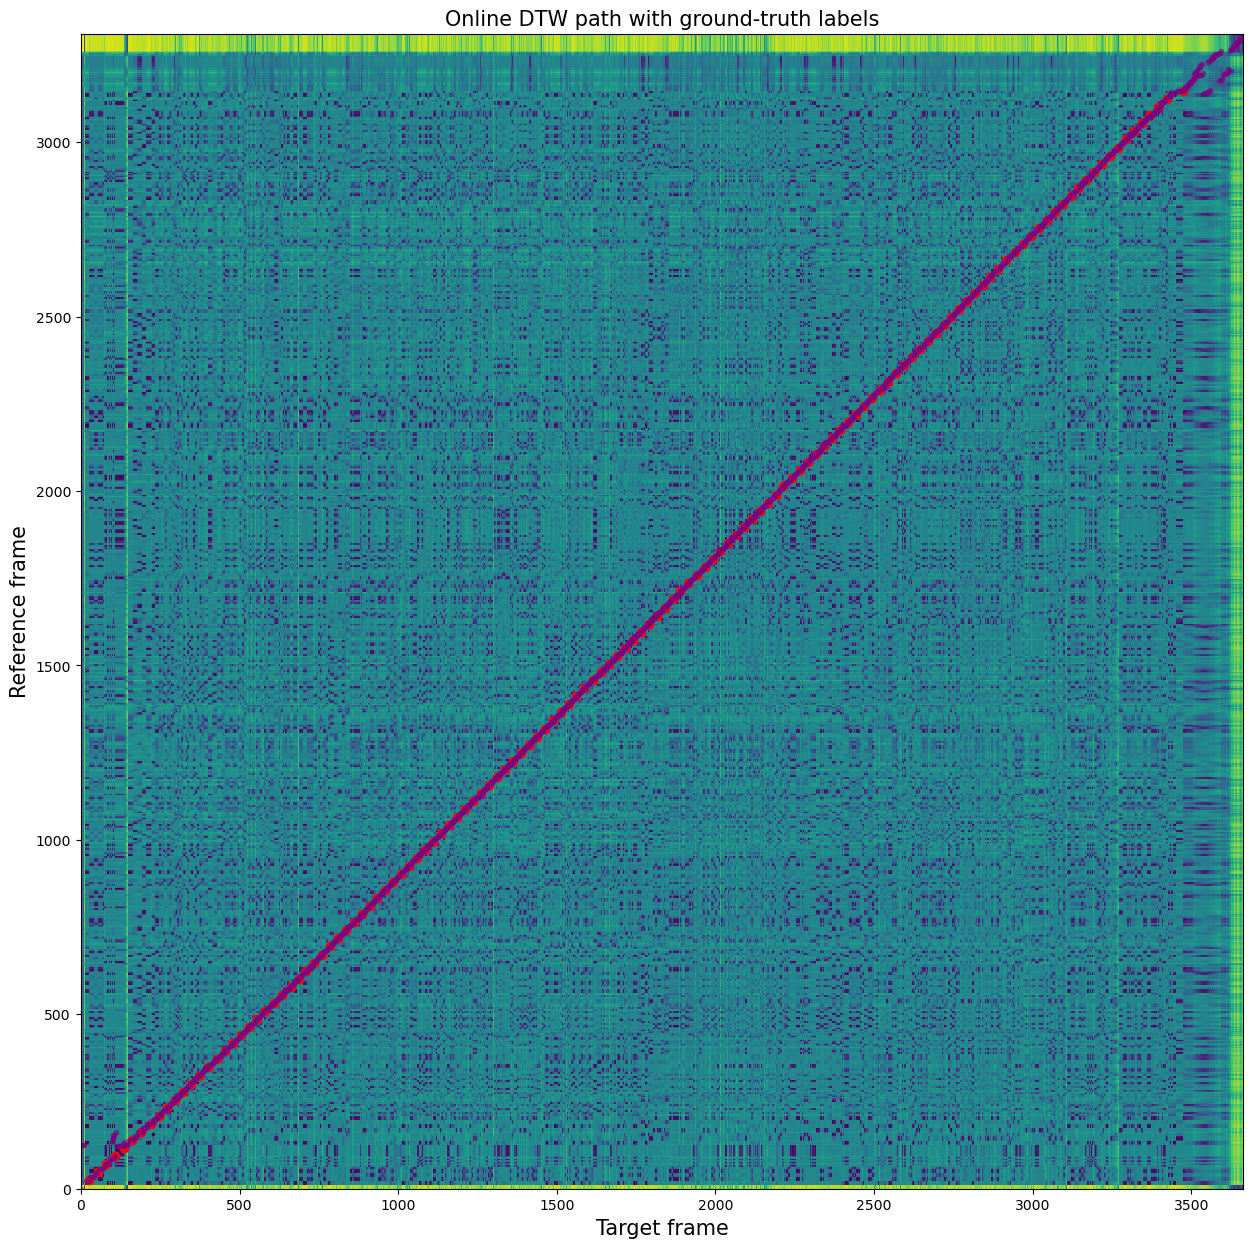

In [5]:
# visualize online DTW path
dist = scipy.spatial.distance.cdist(
    oltw.reference_features.T,
    oltw.input_features[:, : oltw.target_pointer].T,
    metric=oltw.local_cost_fun,
)  # [d, wy]
plt.figure(figsize=(15, 15))
plt.imshow(dist, aspect="auto", origin="lower", interpolation="nearest")
plt.title("Online DTW path with ground-truth labels", fontsize=15)
plt.xlabel("Target frame", fontsize=15)
plt.ylabel("Reference frame", fontsize=15)

# plot ground-truth labels
for ref, target in zip(ref_annots, target_annots):
    plt.plot(target * FRAME_RATE, ref * FRAME_RATE, "o", color="r", alpha=1)

# plot online DTW path
ref_paths, target_paths = oltw.wp[0], oltw.wp[1]
for n in range(len(ref_paths)):
    plt.plot(target_paths[n], ref_paths[n], ".", color="purple", alpha=0.5)

## Example of Offline Dynamic Time Warping (DTW) score following with audio input (using synctoolbox)

In [6]:
import librosa
from synctoolbox.dtw.mrmsdtw import sync_via_mrmsdtw

In [7]:
score_audio_path = "./resources/ex_midi_score.wav"
target_audio_path = "./resources/ex_VuV01M.wav"

ref_audio, _ = librosa.load(score_audio_path, sr=SAMPLE_RATE)
target_audio, _ = librosa.load(target_audio_path, sr=SAMPLE_RATE)

# extract chroma stft features (same feature as online DTW example above)
reference_features = librosa.feature.chroma_stft(y=ref_audio, sr=SAMPLE_RATE, hop_length=HOP_LENGTH)
target_features = librosa.feature.chroma_stft(y=target_audio, sr=SAMPLE_RATE, hop_length=HOP_LENGTH)

wp = sync_via_mrmsdtw(
    f_chroma1=reference_features,
    f_chroma2=target_features,
    input_feature_rate=FRAME_RATE,
)
target_annots_predicted = transfer_positions(wp, ref_annots, FRAME_RATE)
errors_in_delay = (target_annots - target_annots_predicted) * 1000  # in milliseconds
absolute_errors_in_delay = np.abs(errors_in_delay)

results = {
    "mean": np.mean(absolute_errors_in_delay),
    "median": np.median(absolute_errors_in_delay),
    "std": np.std(absolute_errors_in_delay),
    "skewness": scipy.stats.skew(errors_in_delay),
}
TOLERANCES = [50, 100, 200, 300, 500]
for tau in TOLERANCES:
    results[f"{tau}ms"] = np.mean(absolute_errors_in_delay <= tau)

print(results)

{'mean': 23.798426470418182, 'median': 18.61049999955, 'std': 23.2487919149692, 'skewness': 0.38700147748217084, '50ms': 0.9117647058823529, '100ms': 0.9926470588235294, '200ms': 1.0, '300ms': 1.0, '500ms': 1.0}


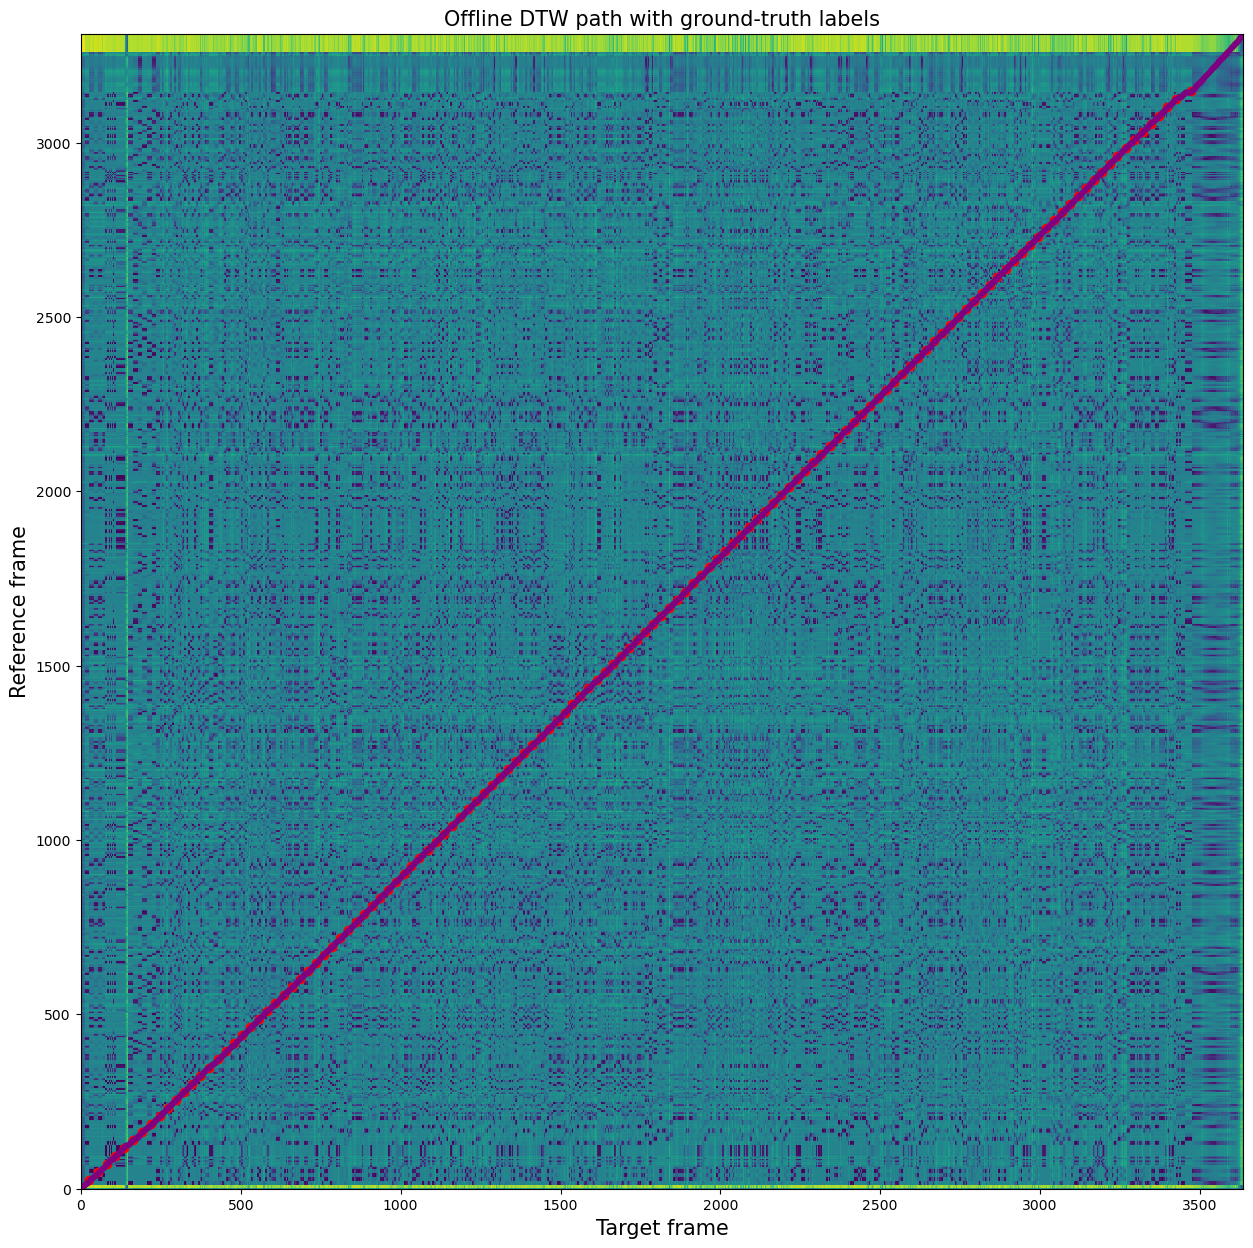

In [8]:
# visualize online DTW path
dist = scipy.spatial.distance.cdist(
    reference_features.T,
    target_features.T,
    metric=oltw.local_cost_fun,  # same cost function as online DTW
)  # [d, wy]
plt.figure(figsize=(15, 15))
plt.imshow(dist, aspect="auto", origin="lower", interpolation="nearest")
plt.title("Offline DTW path with ground-truth labels", fontsize=15)
plt.xlabel("Target frame", fontsize=15)
plt.ylabel("Reference frame", fontsize=15)

# plot ground-truth labels
for ref, target in zip(ref_annots, target_annots):
    plt.plot(target * FRAME_RATE, ref * FRAME_RATE, "o", color="r", alpha=1)

# plot online DTW path
ref_paths, target_paths = wp[0], wp[1]
for n in range(len(ref_paths)):
    plt.plot(target_paths[n], ref_paths[n], ".", color="purple", alpha=0.5)